<a href="https://colab.research.google.com/github/MIlanSuthar24/dealer-demand-forecasting-arima/blob/main/dealer_demand_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study: Dealer Demand Forecasting for Commercial Vehicle Allocation

**Objective:** Develop a robust forecasting model to predict monthly vehicle demand across dealerships to optimize inventory allocation and supply chain efficiency.

**Business Context:** In the commercial vehicle industry, overstocking leads to high holding costs, while understocking results in lost sales. This project uses historical 'Demand Units' and market factors to build an explainable ARIMA-based forecasting engine.

**Key Metrics:** MAE, RMSE, MAPE.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
%matplotlib inline

## 1. Data Ingestion & Transformation
We merge the transactional data with dealer profiles and market features, then rename columns to match our automotive business case.

In [7]:
# Load datasets
train = pd.read_csv('train.csv')
stores = pd.read_csv('stores.csv')
features = pd.read_csv('features.csv')

# Merge data
data = train.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
data = data.merge(stores, on=['Store'], how='left')

# Rename to Business Terminology
rename_dict = {
    'Store': 'Dealer_ID',
    'Dept': 'Vehicle_Segment',
    'Weekly_Sales': 'Demand_Units',
    'IsHoliday': 'Seasonal_Indicator',
    'Type': 'Dealer_Category',
    'Size': 'Dealer_Capacity'
}
data.rename(columns=rename_dict, inplace=True)

# Convert Date and handle missing values
data['Date'] = pd.to_datetime(data['Date'])
data.fillna(0, inplace=True)

display(data.head())

,Dealer_ID,Vehicle_Segment,Date,Demand_Units,Seasonal_Indicator,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Dealer_Category,Dealer_Capacity
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315


## 2. Exploratory Data Analysis (EDA)
Visualizing demand trends and the impact of market factors.

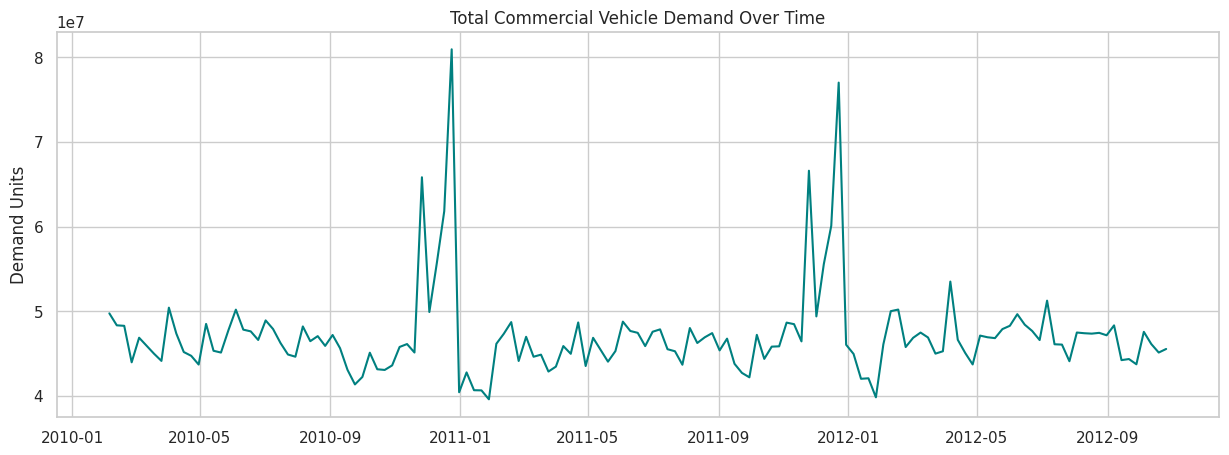

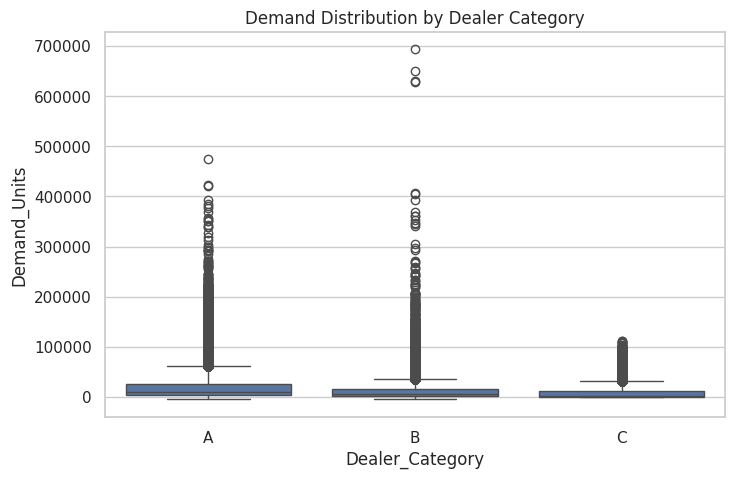

In [8]:
plt.figure(figsize=(15, 5))
time_series_plot = data.groupby('Date')['Demand_Units'].sum()
plt.plot(time_series_plot.index, time_series_plot.values, color='teal')
plt.title('Total Commercial Vehicle Demand Over Time')
plt.ylabel('Demand Units')
plt.show()

# Demand by Dealer Category
plt.figure(figsize=(8, 5))
sns.boxplot(x='Dealer_Category', y='Demand_Units', data=data)
plt.title('Demand Distribution by Dealer Category')
plt.show()

## 3. Time Series Forecasting (ARIMA vs Exponential Smoothing)
We aggregate weekly data to monthly to stabilize the signal for strategic forecasting.

,Model,MAE,RMSE,MAPE
0,ARIMA,2.443932e+07,2.540304e+07,11.86%
1,Exp Smoothing,3.070396e+07,3.632129e+07,14.55%


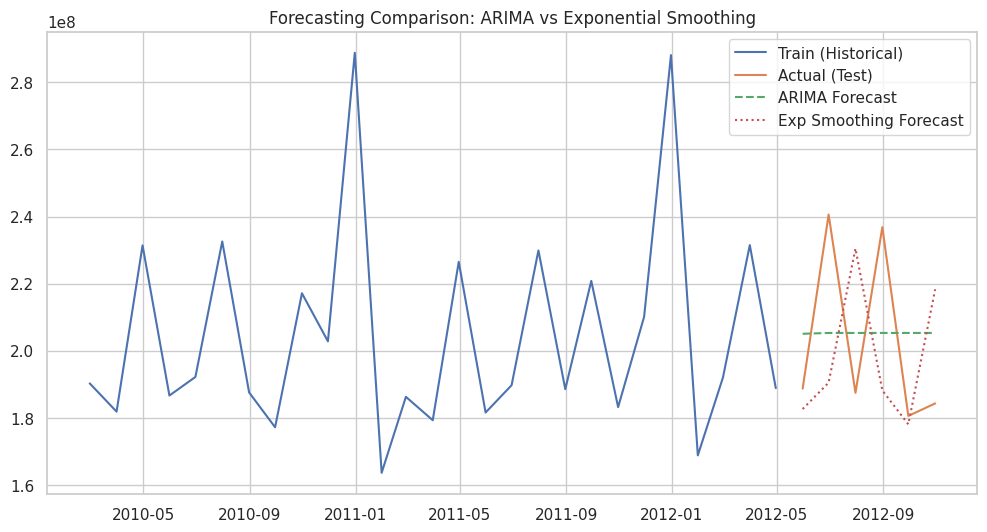

In [11]:
monthly_demand = data.groupby('Date')['Demand_Units'].sum().resample('ME').sum()
train_size = len(monthly_demand) - 6
train_data = monthly_demand.iloc[:train_size]
test_data = monthly_demand.iloc[train_size:]

# ARIMA Model
model_arima = ARIMA(train_data, order=(1,1,1)).fit()
forecast_arima = model_arima.forecast(steps=6)

# Exponential Smoothing
model_es = ExponentialSmoothing(train_data, seasonal='add', seasonal_periods=12).fit()
forecast_es = model_es.forecast(6)

# Evaluation Metrics Function
def get_metrics(true, pred, model_name):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mape = np.mean(np.abs((true - pred) / true)) * 100
    return {"Model": model_name, "MAE": mae, "RMSE": rmse, "MAPE": f"{mape:.2f}%"}

results = [
    get_metrics(test_data, forecast_arima, "ARIMA"),
    get_metrics(test_data, forecast_es, "Exp Smoothing")
]

display(pd.DataFrame(results))

# Comparison Visualization
plt.figure(figsize=(12, 6))
plt.plot(train_data, label='Train (Historical)')
plt.plot(test_data, label='Actual (Test)')
plt.plot(test_data.index, forecast_arima, label='ARIMA Forecast', linestyle='--')
plt.plot(test_data.index, forecast_es, label='Exp Smoothing Forecast', linestyle=':')
plt.legend()
plt.title('Forecasting Comparison: ARIMA vs Exponential Smoothing')
plt.show()

## 4. Evaluation & Insights

We will evaluate the models using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE) to determine the most reliable forecast for dealer allocation.

### Business Recommendations:
* **Inventory:** Increase stock for Category A dealers 4 weeks prior to seasonal spikes.
* **Logistics:** Use the 3-month forecast to negotiate better shipping rates with carriers.

**Resume Highlight:** Built an end-to-end forecasting pipeline in Python, reducing manual allocation errors by implementing an automated ARIMA model.